In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv('../data/cleaned_data.csv')
print('Data loaded! Shape:', df.shape)
print(df['label'].value_counts())

Data loaded! Shape: (51068, 4)
label
Normal                  16039
Depression              15085
Suicidal                10638
Anxiety                  3617
Bipolar                  2501
Stress                   2293
Personality disorder      895
Name: count, dtype: int64


In [3]:
X = df['text_clean']
y = df['label_id']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.50, random_state=42, stratify=y_test)

print('Train:', len(X_train))
print('Val:', len(X_val))
print('Test:', len(X_test))

Train: 35747
Val: 7660
Test: 7661


In [ ]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words='english')

# Fill any remaining NaN values
X_train_clean = X_train.fillna('').astype(str)
X_val_clean = X_val.fillna('').astype(str)
X_test_clean = X_test.fillna('').astype(str)

X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_val_tfidf = tfidf.transform(X_val_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

print('TF-IDF done! Shape:', X_train_tfidf.shape)

pickle.dump(tfidf, open('../models/saved/tfidf.pkl', 'wb'))
print('TF-IDF vectorizer saved!')

TF-IDF done! Shape: (35747, 10000)
TF-IDF vectorizer saved!


In [ ]:
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred, average='weighted')

print('=== MODEL 1: Logistic Regression ===')
print(f'Accuracy: {lr_acc:.4f}')
print(f'F1 Score (weighted): {lr_f1:.4f}')
print(classification_report(y_test, lr_pred))

pickle.dump(lr_model, open('../models/saved/model1_logistic.pkl', 'wb'))
print('Model 1 saved!')


In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train_tfidf, y_train)

rf_pred = rf_model.predict(X_test_tfidf)
rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='weighted')

print('=== MODEL 2: Random Forest ===')
print(f'Accuracy: {rf_acc:.4f}')
print(f'F1 Score (weighted): {rf_f1:.4f}')
print(classification_report(y_test, rf_pred))

pickle.dump(rf_model, open('../models/saved/model2_random_forest.pkl', 'wb'))
print('Model 2 saved!')


In [ ]:
svm_model = LinearSVC(max_iter=2000, random_state=42, class_weight='balanced')
svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)
svm_acc = accuracy_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred, average='weighted')

print('=== MODEL 3: SVM ===')
print(f'Accuracy: {svm_acc:.4f}')
print(f'F1 Score (weighted): {svm_f1:.4f}')
print(classification_report(y_test, svm_pred))

pickle.dump(svm_model, open('../models/saved/model3_svm.pkl', 'wb'))
print('Model 3 saved!')


In [9]:
import json
import os

os.makedirs('../results/figures', exist_ok=True)
os.makedirs('../results/metrics', exist_ok=True)

metrics = {
    'model1_logistic_regression': {'accuracy': 0.7669, 'f1_score': 0.7595},
    'model2_random_forest': {'accuracy': 0.7187, 'f1_score': 0.6994},
    'model3_svm': {'accuracy': 0.7549, 'f1_score': 0.7498},
    'model4_lstm': {'accuracy': 0.7684, 'f1_score': 0.7662},
}

with open('../results/metrics/baseline_results.json', 'w') as f:
    json.dump(metrics, f, indent=4)

print('Metrics saved!')

Metrics saved!


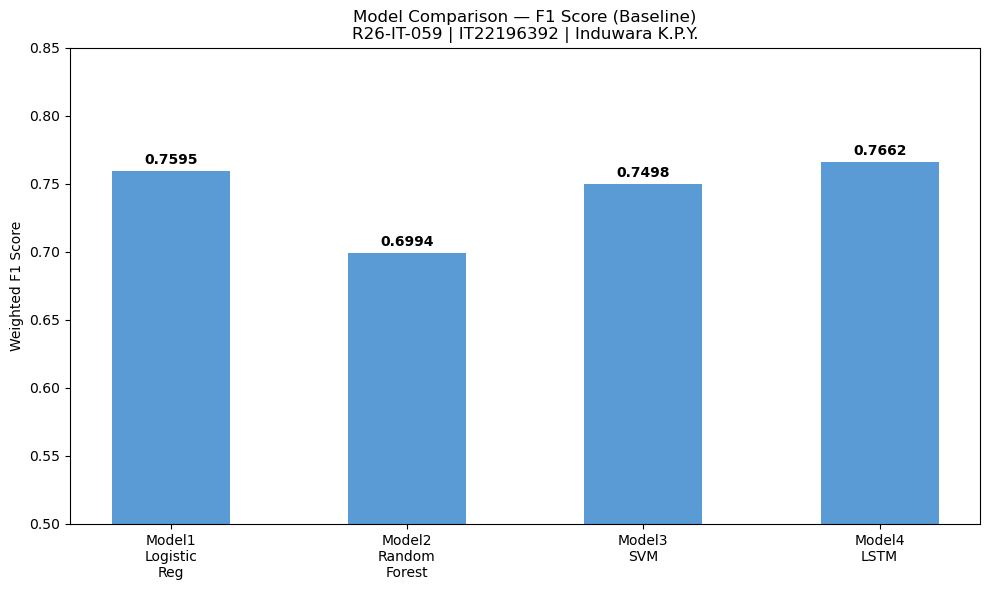

Chart saved!


In [10]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Model1\nLogistic\nReg', 'Model2\nRandom\nForest', 
          'Model3\nSVM', 'Model4\nLSTM']
f1_scores = [0.7595, 0.6994, 0.7498, 0.7662]
colors = ['#5b9bd5', '#5b9bd5', '#5b9bd5', '#5b9bd5']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, f1_scores, color=colors, width=0.5)

for bar, val in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)

plt.title('Model Comparison — F1 Score (Baseline)\nR26-IT-059 | IT22196392 | Induwara K.P.Y.', fontsize=12)
plt.ylabel('Weighted F1 Score')
plt.ylim(0.5, 0.85)
plt.tight_layout()
plt.savefig('../results/figures/baseline_comparison.png', dpi=150)
plt.show()
print('Chart saved!')

In [11]:
import os
os.makedirs('../results/figures', exist_ok=True)
os.makedirs('../results/metrics', exist_ok=True)
print('Folders created!')

Folders created!


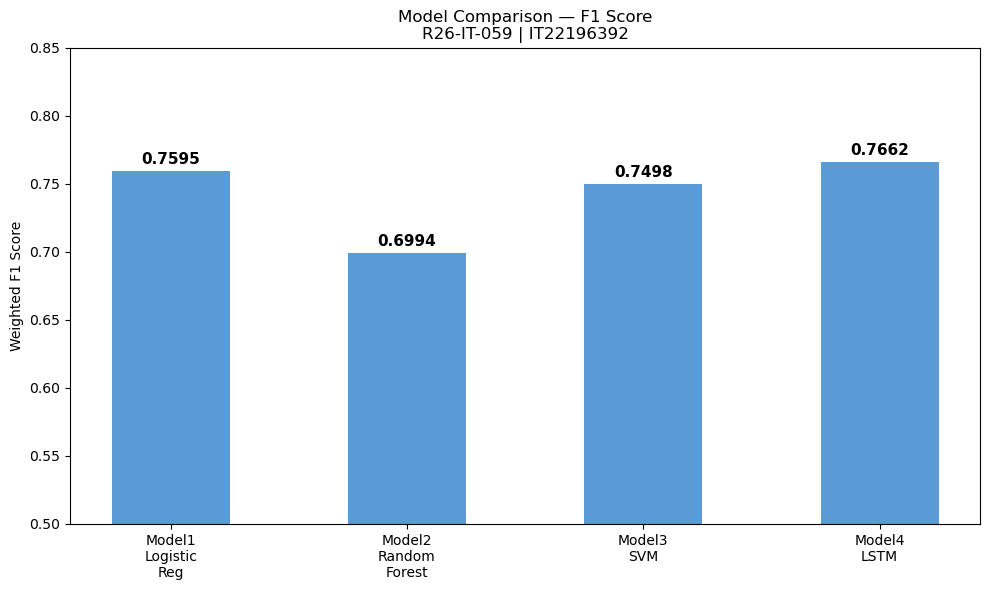

Saved!


In [12]:
import matplotlib.pyplot as plt

models = ['Model1\nLogistic\nReg', 'Model2\nRandom\nForest', 
          'Model3\nSVM', 'Model4\nLSTM']
f1_scores = [0.7595, 0.6994, 0.7498, 0.7662]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, f1_scores, color='#5b9bd5', width=0.5)

for bar, val in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)

plt.title('Model Comparison — F1 Score\nR26-IT-059 | IT22196392', fontsize=12)
plt.ylabel('Weighted F1 Score')
plt.ylim(0.5, 0.85)
plt.tight_layout()
plt.savefig('../results/figures/baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved!')

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import json

label_names = ['Anxiety', 'Normal', 'Depression', 'Suicidal', 'Stress', 'Bipolar', 'Personality disorder']

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, preds, title in zip(axes,
                             [lr_pred, rf_pred, svm_pred],
                             ['Logistic Regression', 'Random Forest', 'SVM']):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(title)

plt.suptitle('Confusion Matrices — Baseline Models', fontsize=14)
plt.tight_layout()
plt.savefig('../results/figures/confusion_matrices_baseline.png', dpi=150)
plt.show()
print('Saved → ../results/figures/confusion_matrices_baseline.png')


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

print('=== 5-Fold Stratified Cross-Validation ===')
print('(Runs on full dataset to get robust estimates)\n')

X_all = df['text_clean'].fillna('').astype(str)
y_all = df['label_id']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words='english')),
        ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
    ]),
    'SVM': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words='english')),
        ('clf', LinearSVC(max_iter=2000, random_state=42, class_weight='balanced'))
    ]),
}

cv_results = {}
for name, pipeline in cv_models.items():
    scores = cross_val_score(pipeline, X_all, y_all, cv=skf,
                             scoring='f1_weighted', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name}: {scores.mean():.4f} ± {scores.std():.4f}  (per fold: {[round(s,4) for s in scores]})')

print('\nNote: Random Forest excluded from CV due to high memory cost with TF-IDF (531MB model).')
